In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from matplotlib import pyplot as plt
import xarray as xr
import numpy as np

# Figure 7-8: Collision-Sedimentation Only

## 1. Run PySDM Case

In [11]:
from PySDM_examples.Shipway_and_Hill_2012 import Simulation, Settings
from PySDM_examples.deJong_Azimi import Settings1D
from PySDM.dynamics.collisions.collision_kernels import Golovin, Long1974
from PySDM import Formulae
from PySDM.initialisation import spectra
from PySDM.exporters import NetCDFExporter_1d
from PySDM.physics import si, in_unit

In [24]:
params = {
    "n_sd_per_gridbox": 512,
    "dt": 1 * si.s,
    "dz": 50 * si.m,
    "p0": 1e5 * si.Pa,
    "particles_per_volume_STP": 10 / si.cm**3,
    "t_max": 1500 * si.s,
    "z_part": (0.5, 0.75),
    "rho_times_w_1": 0 * si.kg/si.m**3 * si.m/si.s,
}
settings = Settings1D(**params)
rho_dry = 1.0 * si.kg / si.m**3
norm_factor_STP = (params["particles_per_volume_STP"] / 
    rho_dry *
    (params["z_part"][1] - params["z_part"][0])
)

# Change the kernel
settings.collision_kernel = Long1974()

# Compute the correct initial spectrum
QT = 1e-3 
k = 2
mt = QT * rho_dry
theta_v = mt / k / params["particles_per_volume_STP"] / settings.formulae.constants.rho_w
settings.wet_radius_spectrum_per_mass_of_dry_air = spectra.Gamma(
    norm_factor = norm_factor_STP,
    k = k,
    theta = theta_v,
)

simulation = Simulation(settings)
output = simulation.run().products

# save data
filename = "../results/pysdm/pysdm_colSed_partDomain_N0=10.nc"
nc_exporter = NetCDFExporter_1d(output, settings, simulation, filename)
nc_exporter.run()

## 2. Open Datasets and plot results

In [26]:
datasets = {
    "PySDM": xr.open_dataset("../results/pysdm/pysdm_colSed_partDomain_N0=10.nc"),
    "Flexible4M": xr.open_dataset("./Output_KiD_col_sed/CloudyPrecip_4/Flexible_4M,_Long.nc", group="profiles"),
    "Flexible7M": xr.open_dataset("./Output_KiD_col_sed/CloudyPrecip_7/Flexible_7M,_Long.nc", group="profiles"),
    "2M-SB2006": xr.open_dataset("./Output_KiD_col_sed/Precipitation2M/2M,_SB2006.nc", group="profiles"),
    "1M-Kessler": xr.open_dataset("./Output_KiD_col_sed/Precipitation1M/1M,_Kessler.nc", group="profiles"),
}
datasets["PySDM"]['time'] = datasets["PySDM"]['time'].astype('timedelta64[s]').astype(float)
datasets["PySDM"]['cloud water mixing ratio'] /= 1000 # g/kg -> kg/kg
datasets["PySDM"]['rain water mixing ratio'] /= 1000 # g/kg

datasets["1M-Kessler"]["N_liq"] *= np.nan # default fill value is 9e+36; this is just to make sure that it doesn't show up in the plots
datasets["1M-Kessler"]["N_rai"] *= np.nan

/var/folders/p0/4_dx18lx2hg2t2d47ltv2r8m00223t/T/ipykernel_75762/3676157552.py:2: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  "PySDM": xr.open_dataset("../results/pysdm/pysdm_colSed_partDomain_N0=10.nc"),


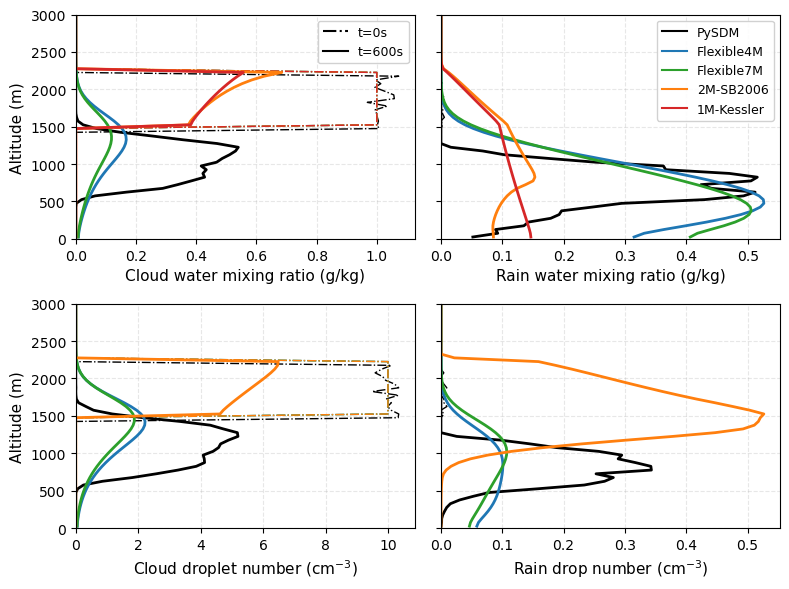

In [27]:
from plotting_utils import plot_vertical_profiles

fig, ax = plot_vertical_profiles(datasets, figsize=(8, 6), t_plt=[0, 600], lw=[1, 2])
fig.savefig("../figures/fig7_colsed_profiles.pdf")


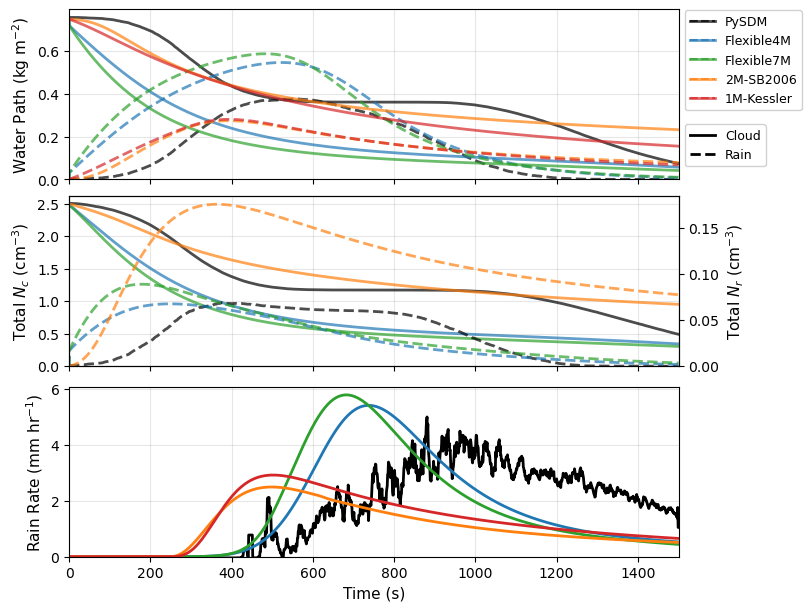

In [28]:
from plotting_utils import plot_time_series

fig, ax = plot_time_series(datasets, figsize=(8, 6), tmax=1500)
fig.savefig("../figures/fig8_colsed_series.pdf", bbox_inches='tight')

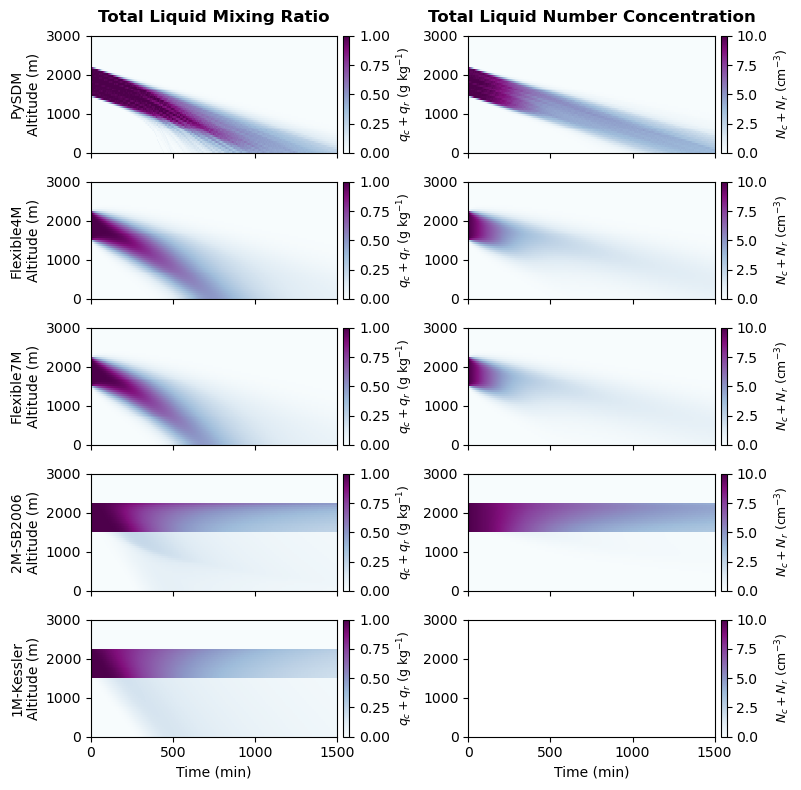

In [29]:
from plotting_utils import plot_timeheight_comparison

fig, ax = plot_timeheight_comparison(datasets, figsize=(8, 8), vmax_q=1.0, vmax_N = 10)
fig.savefig("../figures/figA3_colsed_timeheight.pdf")

# Fig 9-10: Full KiD simulation

## 1. Run PySDM

In [22]:
from PySDM_examples.Shipway_and_Hill_2012 import Simulation, Settings, plot
from PySDM_examples.deJong_Azimi import Settings1D
from PySDM.dynamics.collisions.collision_kernels import Golovin, Long1974
from PySDM import Formulae
from PySDM.initialisation import spectra
from PySDM.exporters import NetCDFExporter_1d
from PySDM.physics import si, in_unit

In [23]:
params = {
    "n_sd_per_gridbox": 512,
    "dt": 5 * si.s,
    "dz": 25 * si.m,
    "p0": 990 * si.hPa,
    "kappa": 0.9,
    "particles_per_volume_STP": 100 / si.cm**3,
    "t_max": 3600 * si.s,
    "z_max": 3000 * si.m,
    "rho_times_w_1": 2 * si.kg/si.m**3 * si.m/si.s,
    "collision_kernel": Golovin(b = 5e3 / si.s), #Long1974(),
    "formulae": Formulae(terminal_velocity="PowerSeries")
}
settings = Settings(**params)
simulation = Simulation(settings)
output = simulation.run().products

# save data
filename = "../results/pysdm/pysdm_fullKiD_w=2.nc"
nc_exporter = NetCDFExporter_1d(output, settings, simulation, filename)
nc_exporter.run()

/Users/dejong5/Documents/PySDM/PySDM/backends/numba.py:57: UserWarning: Disabling Numba threading due to ARM64 CPU (atomics do not work yet)
  warnings.warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## 2. Make plots

In [30]:
datasets = {
    "PySDM": xr.open_dataset("../results/pysdm/pysdm_fullKiD_w=2.nc"),
    "Flexible4M": xr.open_dataset("./Output_KiD_full/CloudyMoisture_CloudyPrecip_4/Output.nc", group="profiles"),
    "Flexible7M": xr.open_dataset("./Output_KiD_full/CloudyMoisture_CloudyPrecip_7/Output.nc", group="profiles"),
    "2M-SB2006": xr.open_dataset("./Output_KiD_full/EquilibriumMoisture_Precipitation2M_SB2006/Output.nc", group="profiles"),
    "1M-Kessler": xr.open_dataset("./Output_KiD_full/EquilibriumMoisture_Precipitation1M_CliMA_1M/Output.nc", group="profiles")
}
    
datasets["PySDM"]['time'] = datasets["PySDM"]['time'].astype('timedelta64[s]').astype(float)
datasets["PySDM"]['cloud water mixing ratio'] /= 1000 # g/kg -> kg/kg
datasets["PySDM"]['rain water mixing ratio'] /= 1000 # g/kg

datasets["1M-Kessler"]["N_liq"] *= np.nan # default fill value is 9e+36; this is just to make sure that it doesn't show up in the plots
datasets["1M-Kessler"]["N_rai"] *= np.nan

/var/folders/p0/4_dx18lx2hg2t2d47ltv2r8m00223t/T/ipykernel_75762/3650051051.py:2: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  "PySDM": xr.open_dataset("../results/pysdm/pysdm_fullKiD_w=2.nc"),


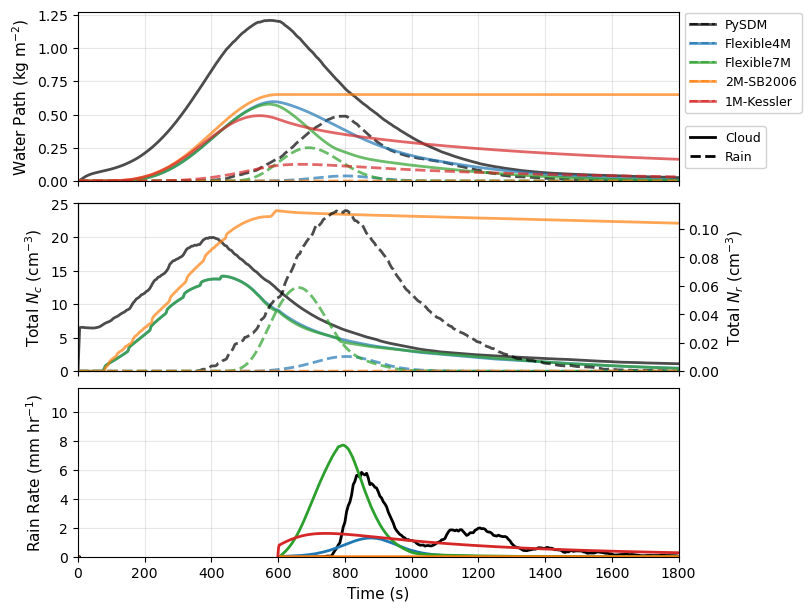

In [31]:
from plotting_utils import plot_time_series

fig, ax = plot_time_series(datasets, figsize=(8, 6), tmax=1800)
fig.savefig("../figures/fig10_KiD_series.pdf")

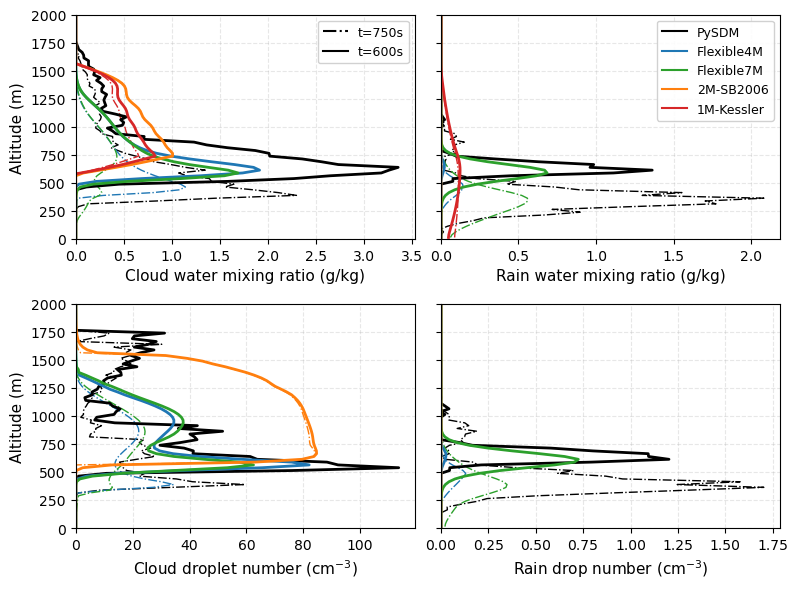

In [41]:
from plotting_utils import plot_vertical_profiles

fig, ax = plot_vertical_profiles(datasets, figsize=(8, 6), t_plt=[750, 600], lw=[1, 2], ylim=2000)
fig.savefig("../figures/fig9_KiD_profiles.pdf")


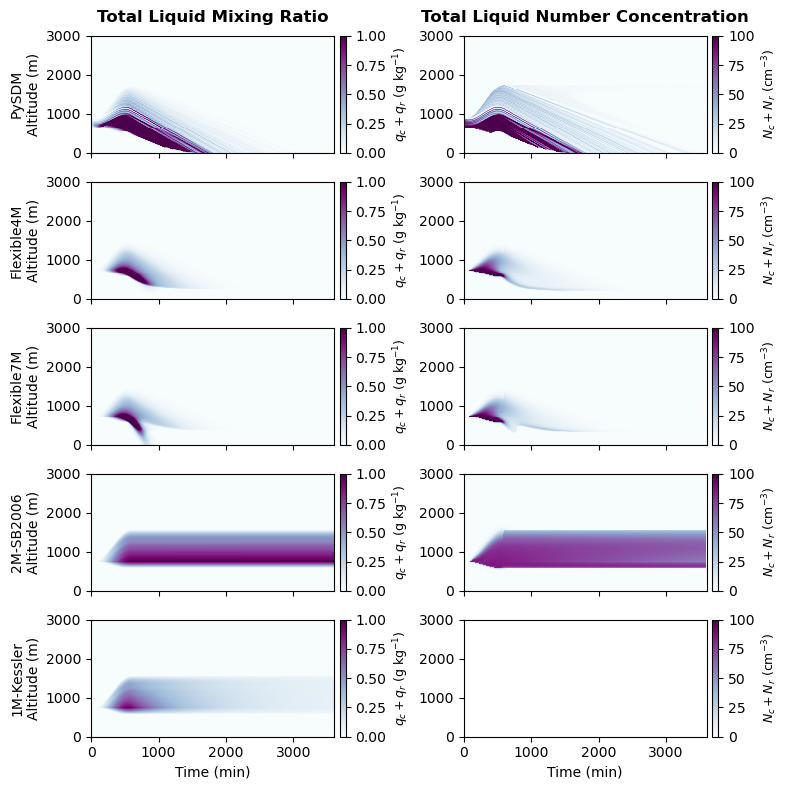

In [61]:
from plotting_utils import plot_timeheight_comparison

fig, ax = plot_timeheight_comparison(datasets, figsize=(8, 8), vmax_q=1.0, vmax_N = 100)
fig.savefig("../figures/figA4_fullKiD_timeheight.pdf")